# Project analysis - IT jobs situation over the years

In [116]:
import requests
import json
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import country_converter as coco

In [117]:
URL_API = 'https://upy-homeworks.xpert-ia.com.mx/visualization-tools/'

Getting a sample (10 records) of the data available in the database using the API.

In [118]:
"""response_sample = requests.get(url=f'{URL_API}api/postgres', params={
    'table': 'jobs_proyect_u2',
    'limit': 10
})
payload_sample = response_sample.json()
payload_sample"""

"response_sample = requests.get(url=f'{URL_API}api/postgres', params={\n    'table': 'jobs_proyect_u2',\n    'limit': 10\n})\npayload_sample = response_sample.json()\npayload_sample"

Getting all the records available in the database.

In [119]:
"""response = requests.get(url=f'{URL_API}api/postgres', params={
    'table': 'jobs_proyect_u2'
})
payload = response.json()"""

"response = requests.get(url=f'{URL_API}api/postgres', params={\n    'table': 'jobs_proyect_u2'\n})\npayload = response.json()"

### Transforming the JSON response into a dataframe

In [120]:
"""base_df = pd.json_normalize(payload['data']).drop(columns=['id']).sort_values(by='work_year')
base_df"""

"base_df = pd.json_normalize(payload['data']).drop(columns=['id']).sort_values(by='work_year')\nbase_df"

Saving the data into a file to avoid calling the API multiple times.

In [121]:
"""base_df.to_csv('./data/projectU2.csv', index= False)"""

"base_df.to_csv('./data/projectU2.csv', index= False)"

# Getting the data from CSV

Loading the base dataset

In [122]:
base_df = pd.read_csv('./data/projectU2.csv').drop(columns=['created_at', 'updated_at'])
base_df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,0,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,100,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,50,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,100,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,0,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,2025,MI,FT,Security Engineer,80000,USD,80000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65113,2025,MI,FT,Security Engineer,120000,USD,120000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65114,2025,MI,CT,Security Engineer,120000,USD,120000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65115,2025,MI,CT,Security Engineer,130000,USD,130000,US,0,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos


In [123]:
columns = list(base_df.columns)
print(columns)

['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'category', 'subcategory', 'department', 'employee_latitude', 'employee_longitude', 'employee_country_name', 'company_latitude', 'company_longitude', 'company_country_name']


In [124]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65117 entries, 0 to 65116
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   work_year              65117 non-null  int64  
 1   experience_level       65117 non-null  object 
 2   employment_type        65117 non-null  object 
 3   job_title              65117 non-null  object 
 4   salary                 65117 non-null  int64  
 5   salary_currency        65117 non-null  object 
 6   salary_in_usd          65117 non-null  int64  
 7   employee_residence     65117 non-null  object 
 8   remote_ratio           65117 non-null  int64  
 9   company_location       65117 non-null  object 
 10  company_size           65117 non-null  object 
 11  category               65117 non-null  object 
 12  subcategory            65117 non-null  object 
 13  department             65117 non-null  object 
 14  employee_latitude      65117 non-null  float64
 15  em

In [125]:
base_df.isnull().sum()

work_year                0
experience_level         0
employment_type          0
job_title                0
salary                   0
salary_currency          0
salary_in_usd            0
employee_residence       0
remote_ratio             0
company_location         0
company_size             0
category                 0
subcategory              0
department               0
employee_latitude        0
employee_longitude       0
employee_country_name    0
company_latitude         0
company_longitude        0
company_country_name     0
dtype: int64

In [126]:
base_df = base_df.replace(to_replace={'remote_ratio': {0: 'Remote', 50: 'Hybrid', 100: 'On-site'}})
base_df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_latitude,employee_longitude,employee_country_name,company_latitude,company_longitude,company_country_name
0,2020,SE,FT,Security Engineer,107000,USD,107000,US,Remote,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
1,2020,MI,FT,Security Engineer,135000,USD,135000,US,On-site,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
2,2020,SE,FT,Security Engineer,148000,USD,148000,US,Hybrid,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
3,2020,SE,FT,Staff Application Security Engineer,180000,USD,180000,US,On-site,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
4,2020,EX,FT,Information Security Manager,117810,USD,117810,US,Remote,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,2025,MI,FT,Security Engineer,80000,USD,80000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65113,2025,MI,FT,Security Engineer,120000,USD,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65114,2025,MI,CT,Security Engineer,120000,USD,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos
65115,2025,MI,CT,Security Engineer,130000,USD,130000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,37.090240,-95.71289,Estados Unidos,37.090240,-95.71289,Estados Unidos


# Time series analysis

## _**Temporal analysis**_

### **PROVISIONAL IDEA TO ENHANCE THE TEMPORAL ANALYSIS IF THE BASE DATASET IS NOT ENOUGH**

For an enhanced temporal analysis, we will add another dataset in order to make, for example, ACF and CCF. The new dataset is ``jobs_ai_skills.csv``, which contains the increase of jobs (in certain countries from 2020 to 2025) that list AI skills as requirements.

In [127]:
support_df = pd.read_csv('./data/jobs_ai_skills.csv').rename(columns={'Share of artificial intelligence jobs among all job postings': 'Jobs_ai_skills(%)'})
support_df = support_df[support_df['Year'] >= 2020]
support_df

,Entity,Code,Year,Jobs_ai_skills(%)
6,Australia,AUS,2020,0.82
7,Australia,AUS,2021,1.17
8,Australia,AUS,2022,1.11
9,Australia,AUS,2023,0.91
10,Australia,AUS,2024,1.14
...,...,...,...,...
129,United States,USA,2020,1.37
130,United States,USA,2021,1.49
131,United States,USA,2022,1.69
132,United States,USA,2023,1.39


In [128]:
"""base_df = base_df.merge(right=[support_df], left_on='')"""

"base_df = base_df.merge(right=[support_df], left_on='')"

## _**Spatial analysis**_

In [129]:
"""geo_df = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
geo_df"""

'geo_df = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")\ngeo_df'

In [130]:
"""geo_df.plot()"""

'geo_df.plot()'

## _**Spatiotemporal analysis**_

# Hierarchical analysis

In [131]:
base_df['department'].unique()

array(['Cybersecurity', 'Executive & Leadership',
       'Engineering & Development', 'Operations', 'Data & Analytics',
       'Sales & Consulting', 'Information Technology (IT)',
       'Finance & Accounting', 'Legal & Compliance',
       'Human Resources (HR)', 'Product Management'], dtype=object)

['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'category', 'subcategory', 'department', 'employee_latitude', 'employee_longitude', 'employee_country_name', 'company_latitude', 'company_longitude', 'company_country_name']

In [132]:
jobs_df = base_df.drop(columns=['work_year', 'employee_latitude', 'employee_longitude', 'company_latitude', 'company_longitude', 'salary', 'salary_currency'])
jobs_df

,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,category,subcategory,department,employee_country_name,company_country_name
0,SE,FT,Security Engineer,107000,US,Remote,US,L,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
1,MI,FT,Security Engineer,135000,US,On-site,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
2,SE,FT,Security Engineer,148000,US,Hybrid,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
3,SE,FT,Staff Application Security Engineer,180000,US,On-site,US,L,Application Security & DevSecOps,Application Security,Cybersecurity,Estados Unidos,Estados Unidos
4,EX,FT,Information Security Manager,117810,US,Remote,US,S,Management & Leadership,Management & Team Leadership,Executive & Leadership,Estados Unidos,Estados Unidos
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65112,MI,FT,Security Engineer,80000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65113,MI,FT,Security Engineer,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65114,MI,CT,Security Engineer,120000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos
65115,MI,CT,Security Engineer,130000,US,Remote,US,M,Security Engineering & Architecture,Security Engineering,Cybersecurity,Estados Unidos,Estados Unidos


In [133]:
departments_list = list(jobs_df['department'].unique())
print(departments_list)

['Cybersecurity', 'Executive & Leadership', 'Engineering & Development', 'Operations', 'Data & Analytics', 'Sales & Consulting', 'Information Technology (IT)', 'Finance & Accounting', 'Legal & Compliance', 'Human Resources (HR)', 'Product Management']


In [134]:
employees_number = []
incomes_per_sub = []
subcategories = []
categories = []
departments = []

for department in departments_list:
    department_df = jobs_df[jobs_df['department'] == department]
    categories_list = department_df['category'].unique()
    for category in categories_list:
        category_df = department_df[department_df['category'] == category]
        subcategories_list = category_df['subcategory'].unique()
        for subcategory in subcategories_list:
            subcategory_df = category_df[category_df['subcategory'] == subcategory]
            income = subcategory_df['salary_in_usd'].sum()
            employees_number.append(subcategory_df['subcategory'].count())
            incomes_per_sub.append(income)
            subcategories.append(subcategory)
            categories.append(category)
            departments.append(department)
    
jobs_df2 = pd.DataFrame({
    'department': departments,
    'category': categories,
    'subcategory': subcategories,
    'employees': employees_number,
    'income': incomes_per_sub
})

jobs_df2


,department,category,subcategory,employees,income
0,Cybersecurity,Security Engineering & Architecture,Security Engineering,16110,2589672695
1,Cybersecurity,Security Engineering & Architecture,General Security Analysis & Administration,8962,1059617253
2,Cybersecurity,Security Engineering & Architecture,Cloud & Network Security,100,15891297
3,Cybersecurity,Security Engineering & Architecture,Identity & Access Management (IAM),307,42049676
4,Cybersecurity,Application Security & DevSecOps,Application Security,44,4104204
...,...,...,...,...,...
78,Finance & Accounting,"Governance, Risk & Compliance (GRC)",Audit & Assurance,249,26696295
79,Finance & Accounting,Threat Intelligence & Forensics,Malware Analysis & Forensics,4,477388
80,Legal & Compliance,"Governance, Risk & Compliance (GRC)",Risk & Compliance,128,18656326
81,Human Resources (HR),Training & Education,Technical Training & Education,8,828299


In [135]:
treemap_chart = px.treemap(
    data_frame= jobs_df2,
    values='income',
    path=['department', 'category', 'subcategory'],
    title='Income per department in USD (2020 - 2025)',
    color='income',  # Color by subcategory income to show the incomes per department
    color_continuous_scale="peach"
)

treemap_chart.update_traces(textinfo="label+value", textfont_size=11)
treemap_chart.update_layout(height=700, width=1000)
treemap_chart.show()

In [136]:
sunburst_chart = px.sunburst(
    data_frame=jobs_df2,
    title='Departments presence in IT',
    height=800,
    path=['department', 'category', 'subcategory'],
    values='employees',
    color='employees',
    color_continuous_scale=px.colors.sequential.Viridis
)

# Customize layout for better display
sunburst_chart.update_layout(
    font=dict(size=12),
    title_x=0.5, # Center the title
)

# Showing the organizational structure
sunburst_chart.show()

In [137]:
"""
def country_potential(department: str = None):
"""

employees_per_country = []
countries = []
countries_investment = []

for country in list(base_df['company_country_name'].unique()):
    countries_df = base_df[base_df['company_country_name'] == country]
    investment = countries_df['salary_in_usd'].sum()
    employees = len(countries_df)
    employees_per_country.append(employees)
    countries.append(country)
    countries_investment.append(investment)

dendrogram_df = pd.DataFrame({'Country': countries, 'Country_investment': countries_investment, 'No_employees': employees_per_country})
dendrogram_df= dendrogram_df.sort_values(by='Country_investment', ascending=False).head(15).drop(index=[0])

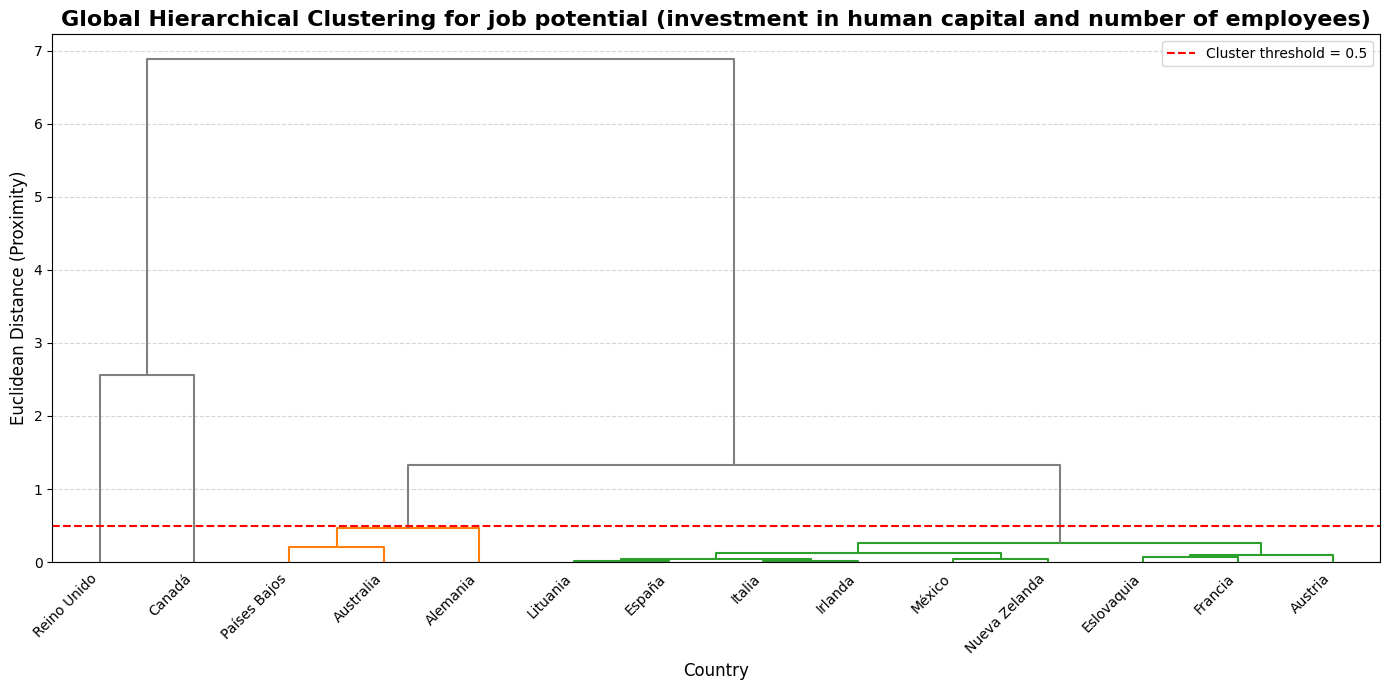

In [138]:
# ------- For euclidean distance --------- #

job_potential = dendrogram_df[['Country_investment', 'No_employees']].values
scaler = StandardScaler()
job_normalized = scaler.fit_transform(job_potential)

X = job_normalized
country_labels = dendrogram_df['Country'].values
distance_matrix = pdist(X, metric='euclidean')
linked = linkage(distance_matrix, method='ward')

# -------- Setting threshold ------------ #

threshold = 0.5 # distance threshold
clusters = fcluster(linked, threshold, criterion='distance')

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    orientation='top',
    labels=country_labels,
    distance_sort='descending',
    show_leaf_counts=True,
    color_threshold=threshold,
    above_threshold_color='gray'
)

# ------------- Plotting the dendrogram ------------ #
plt.title('Global Hierarchical Clustering for job potential (investment in human capital and number of employees)', fontsize=16, weight='bold')
plt.ylabel('Euclidean Distance (Proximity)', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Cluster threshold = {threshold}')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

In [161]:
"""
def country_potential(department: str = None):
"""

for level in list(base_df['experience_level'].unique()):
    levels_df = base_df[base_df['experience_level'] == level]
    level_name = level
    no_employees = levels_df['experience_level'].count()
    level_income = levels_df['salary_in_usd'].sum()
    level_avg_income = levels_df['salary_in_usd'].mean()
    on_site = levels_df[levels_df['remote_ratio'] == 'On-site']['remote_ratio'].count()
    hybrid = levels_df[levels_df['remote_ratio'] == 'Hybrid']['remote_ratio'].count()
    remote = levels_df[levels_df['remote_ratio'] == 'Remote']['remote_ratio'].count()
    freelancer = levels_df[levels_df['employment_type'] == 'FL']['employment_type'].count()
    full_time = levels_df[levels_df['employment_type'] == 'FT']['employment_type'].count()
    part_time = levels_df[levels_df['employment_type'] == 'PT']['employment_type'].count()
    contract = levels_df[levels_df['employment_type'] == 'CT']['employment_type'].count()
    freelancer = levels_df[levels_df['employment_type'] == 'FL']['employment_type'].count()
    if level == 'EN':
        level_name = 'Entry level'
        row_1 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'MI':
        level_name = 'Medium'
        row_2 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'SE':
        level_name = 'Senior'
        row_3 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]
    elif level == 'EX':
        level_name = 'Executive'
        row_4 = [level_name, full_time, part_time, contract, freelancer, no_employees, on_site, hybrid, remote, level_income, level_avg_income]

employees_df = pd.DataFrame(np.array([row_1, row_2, row_3, row_4]), columns=['Level', 'FT_employees', 'PT_employees', 'CT_employees', 'FL_employees', 'No_employees', 'On_site', 'Hybrid', 'Remote', 'Level_income', 'Level_avg_income'])
employees_df = employees_df.astype({'Level': str, 'FT_employees': int, 'PT_employees':int, 'CT_employees': int, 'FL_employees': int, 'No_employees': int, 'On_site': int, 'Hybrid': int, 'Remote': int, 'Level_income': int, 'Level_avg_income': float})
employees_df

,Level,FT_employees,PT_employees,CT_employees,FL_employees,No_employees,On_site,Hybrid,Remote,Level_income,Level_avg_income
0,Entry level,6589,96,15,1,6701,1067,110,5524,681841362,101752.180570
1,Medium,20288,52,32,4,20376,3522,185,16669,2628381419,128993.984050
2,Senior,36214,46,44,6,36310,7933,172,28205,5800194125,159740.956348
3,Executive,1726,2,2,0,1730,416,35,1279,337612333,195151.637572


In [162]:
barchart_fig = px.bar(
    data_frame=employees_df,
    y= 'Level',
    x= 'Level_income',
    orientation='h',
    labels = {'Level': 'Employee level', 'Level_income': 'Avg. income'},
    title='Average income per employee level',
    height=600
)
barchart_fig.update_layout(yaxis={'categoryorder':'total ascending'})
barchart_fig.show()

In [163]:
bubble_chart = px.scatter(
    data_frame=employees_df,
    x= 'No_employees',
    y= 'Level_avg_income',
    size= 'Level_income',
    color='Level',
    hover_name= 'Level',
    title= 'Job potential per level',
    labels={'No_employees': 'Number of employees', 'Level_avg_income': 'Average income (USD)'},
)

bubble_chart.show()

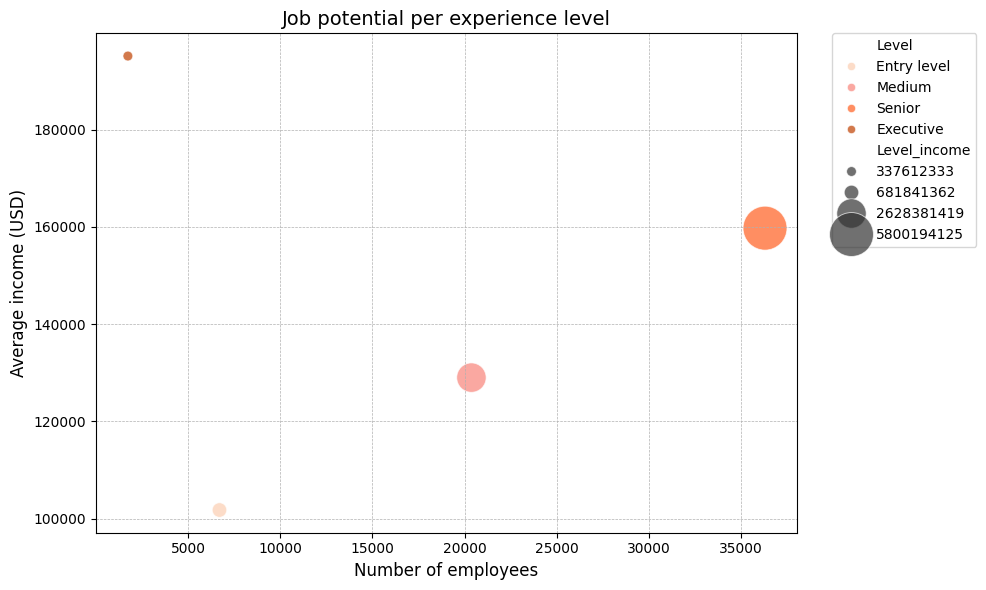

In [172]:
# --- VISUALIZATION 1: External Viability (Scatter Plot) ---
plt.figure(figsize=(10, 6))
# Use log scale for Population to handle the wide range of values effectively
scatter = sns.scatterplot(
    data=employees_df,
    x='No_employees',
    y='Level_avg_income',
    size='Level_income',
    hue='Level',
    sizes=(50, 1000), # Define min/max size for markers
    alpha=0.7,
    palette={'Entry level': '#FBCEB1', 'Medium': '#F88379', 'Senior': '#FF5F1F', 'Executive': '#C04000'}
)

# Add annotations (country codes)
for i, row in employees_df.iterrows():
    plt.annotate(row['Level'], (row['Level_income'], row['Level_avg_income']), fontsize=9)

plt.title('Job potential per experience level', fontsize=14)
plt.xlabel('Number of employees', fontsize=12)
plt.ylabel('Average income (USD)', fontsize=12)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

### Converting dataframes into JSON files for web visualizations

In [173]:
jobs_df2.to_json('./data/jobs_distribution.json', index=False)
dendrogram_df.to_json('./data/jobs_potential_countries.json', index=False)
employees_df.to_json('./data/employees_level.json', index=False)